# DTU Social Data (2026) - Final Project Explainer
**Group Members:** Andrea De Pascale, Edgar Fabregat, Uliyan Sukach

---

## 1. Motivation

**What is your dataset?**
Our analysis uses three datasets:
1. **HFUDD16** (Statistics Denmark): Data on education levels and socioeconomic status (employed, unemployed, enrolled) per municipality.
2. **IFOR35** (Statistics Denmark): Historical average income data per municipality.
3. **Company Data**: Locations and industries of major companies in Denmark fetched from CVR API.

**Why did you choose these particular datasets?**
Combining these datasets allows us to connect a municipality's wealth with its demographics and corporate presence. Instead of just mapping income levels, linking HFUDD16 and IFOR35 lets us analyze the makeup of the local workforce. Adding the company data helps identify if specific industries drive municipal wealth.

**What was your goal for the end user's experience?**
We aimed for a "Martini Glass" structure. We want to present our main findings first (national inflation trends, demographic uniformity, and specific regional anomalies) as the "stem". Then, we open the "glass" by providing an interactive dashboard where users can filter the data and explore individual municipalities themselves.

In [4]:
# Import necessary libraries for the analysis
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Suppress warnings for cleaner notebook presentation
import warnings
warnings.filterwarnings('ignore')

## 2. Basic stats

### Data Cleaning and Preprocessing (Andrea De Pascale)
To create the interactive visualizations, we preprocessed the data as follows:
* **String Normalization:** We standardized municipality names across datasets by removing suffixes (e.g., "Kommune") and standardizing Danish characters (æ, ø, å) to ensure reliable merges.
* **Merging Data:** We merged the `HFUDD16` and `IFOR35` datasets using an inner join on the `Municipality` and `Year` columns.
* **Ratio Calculations:** For the ternary plot, we converted raw population counts into ratios (Employed, Unemployed, Enrolled) per municipality to accurately different regions.


### Exploratory Data Analysis (Andrea De Pascale)
During this exploratory analysis, we plotted the national average income from 2008 to 2024. The data shows a steady, linear increase across the country, which scales as expected with national inflation and wage adjustments.

In [3]:
# Load your merged dataset
df = pd.read_csv('src/Part1/data/Part1_merged_dataset.csv')

# Display the first few rows and basic statistical summary
display(df.head())

# ---------------------------------------------------------
# Plotting the National Inflation Trend
# ---------------------------------------------------------
# Group by year and calculate the mean average income across ALL municipalities
# This creates our baseline "National Trend"
national_trend = df.groupby('Year')['Average Income'].mean().reset_index()

# Filter for the years 2008 to 2024 as mentioned in the text
national_trend = national_trend[(national_trend['Year'] >= 2008) & (national_trend['Year'] <= 2024)]

# Create the line chart
fig_trend = px.line(
    national_trend, 
    x='Year', 
    y='Average Income',
    title="National Average Income Trend (2008-2024)",
    labels={'Average Income': 'Average Income (DKK)', 'Year': 'Year'},
    markers=True
)

# Format the y-axis to include commas for easier reading of large numbers
fig_trend.update_layout(yaxis_tickformat=',')
fig_trend.show()

,Municipality,Year,Average Income,Employed_Ratio,Unemployed_Ratio,Enrolled_Ratio,Outside_Ratio
0,Aabenraa,2008,257029.5,0.587436,0.016870,0.110913,0.284782
1,Aabenraa,2009,255130.2,0.558074,0.034676,0.114738,0.292512
2,Aabenraa,2010,271481.9,0.547915,0.034071,0.121560,0.296454
3,Aabenraa,2011,268613.8,0.536807,0.035979,0.123741,0.303473
4,Aabenraa,2012,268157.0,0.529620,0.039931,0.124723,0.305727


### Data Cleaning and Preprocessing (Edgar Fabregat)
To prepare the company and numerical data for our visualizations, we processed the raw data as follows:
* **Manual Data Collection:** We manually generated our baseline datasets (`src/Part2/data/companies_gross_value.csv` and `src/Part2/data/companies_number_employees.csv`) by annotating the major companies in the top 7 industry sectors in Denmark using [Proff.dk](https://www.proff.dk/), filtering by gross value and number of employees in 2024.
* **Data Transformation:** We cleaned and merged these manual lists, extracting key metrics and generating ready-to-use CSV files (`src/Part2/companies_data_processing.py`) for further integration.
* **Data Retrieval:** We pulled initial datasets directly from the Statistics Denmark database (`src/Part2/StatsBank_retrieval.py`) to form our socioeconomic baseline.
* **API Fetching:** We queried the Danish CVR API (`src/Part2/CVR_API_fetching_processing.py`) to collect detailed company data for our targeted list of major enterprises.
* **Geocoding:** We extracted addresses for the companies' individual production units and mapped them to spatial coordinates (`src/Part2/geocode_production_units.py`). This generated `src/Part2/data/cvr_production_units_geocoded.csv`, which serves as the backbone for our map visualizations.

### Exploratory Data Analysis (Edgar Fabregat)
During this exploratory analysis, we mapped the geographical distribution of enterprise production units across Danish municipalities. By visualizing these corporate locations alongside regional data, we analyzed the patterns regarding how the concentration of major industries is linked with the municipalities average incomes and population.

## 3. Data Analysis

### Part 1: Geographical distribution & Socioeconomic anomalies (Andrea De Pascale)
Analyzing the merged HFUDD16 and IFOR35 datasets revealed two main points:
1. **Demographic uniformity:** The ratios of employed, unemployed, and enrolled individuals are highly similar across all municipalities. Since the workforce composition doesn't change much geographically, regional income differences are likely driven by the types of industries present rather than workforce size or employment rates.
2. **Average income steady increase:** The average income mostly increases gradually for all municipalities from 2008 to 2024, likely due to the inflation rates of the last decades.
3. **The Vejen & Billund anomalies:** In 2023, average incomes spiked in Vejen (from 314k to 446k DKK) and Billund (from 329k to 470k DKK). In 2024, Billund's average income dropped back to 340k DKK, while Vejen's stayed high at 435k DKK.

In [4]:
# ---------------------------------------------------------
# Plotting the Vejen & Billund Anomaly vs. National Baseline
# ---------------------------------------------------------

# 1. Filter for recent years to clearly see the lead-up to the 2023 spike
df_recent = df[df['Year'] >= 2008].copy()

# 2. Create a new category column. 
# If the municipality is Vejen or Billund, it keeps its name. 
# Otherwise, it gets grouped into 'Rest of Denmark'
df_recent['Category'] = df_recent['Municipality'].apply(
    lambda x: x if x in ['Vejen', 'Billund'] else 'Rest of Denmark Average'
)

# 3. Group by Year and the new Category to calculate the mean income
df_anomaly_comparison = df_recent.groupby(['Year', 'Category'])['Average Income'].mean().reset_index()

# 4. Define specific colors so the baseline fades into the background
# and the anomalies stand out brightly.
custom_colors = {
    'Vejen': '#e74c3c',                 # Red
    'Billund': '#3498db',               # Blue
    'Rest of Denmark Average': '#bdc3c7' # Neutral Gray
}

# 5. Create the line chart
fig_anomaly = px.line(
    df_anomaly_comparison, 
    x='Year', 
    y='Average Income', 
    color='Category', 
    color_discrete_map=custom_colors,
    markers=True,
    title="The 2023 income spike vs. the rest of Denmark",
    labels={'Average Income': 'Average Income (DKK)', 'Year': 'Year', 'Category': 'Region'}
)

# 6. Format the y-axis and make the gray line thicker/dashed if desired
fig_anomaly.update_layout(
    yaxis_tickformat=',',
    plot_bgcolor='rgba(240,240,240,0.5)' # Slight background to make lines pop
)

# Optional: Make the baseline line dashed to separate it further from the actual municipalities
fig_anomaly.update_traces(
    patch={"line": {"dash": "dash"}}, 
    selector={"legendgroup": "Rest of Denmark Average"}
)

fig_anomaly.show()

### Part 2: Production Units and Denmark's Demographics (Edgar Fabregat)

When querying the CVR API for production units belonging to Denmark's major companies, we realized some entities naturally dominate the landscape due to their operational model. For example, municipal entities (like "Kommune" and "Region") operate hundreds of small public facilities, and nationwide retail chains/services (like Salling Group, COOP, 365discount, PostNord) operate thousands of individual storefronts or distribution points. 

If we included these in our analysis, they would eclipse traditional industrial and knowledge-based enterprises, skewing our understanding of how high-value industries affect regional wealth. To prevent this from collapsing the scale of our visualizations, we explicitly filtered out municipalities, regions, and major retail/logistics chains before plotting the top enterprise growers and production unit distributions.

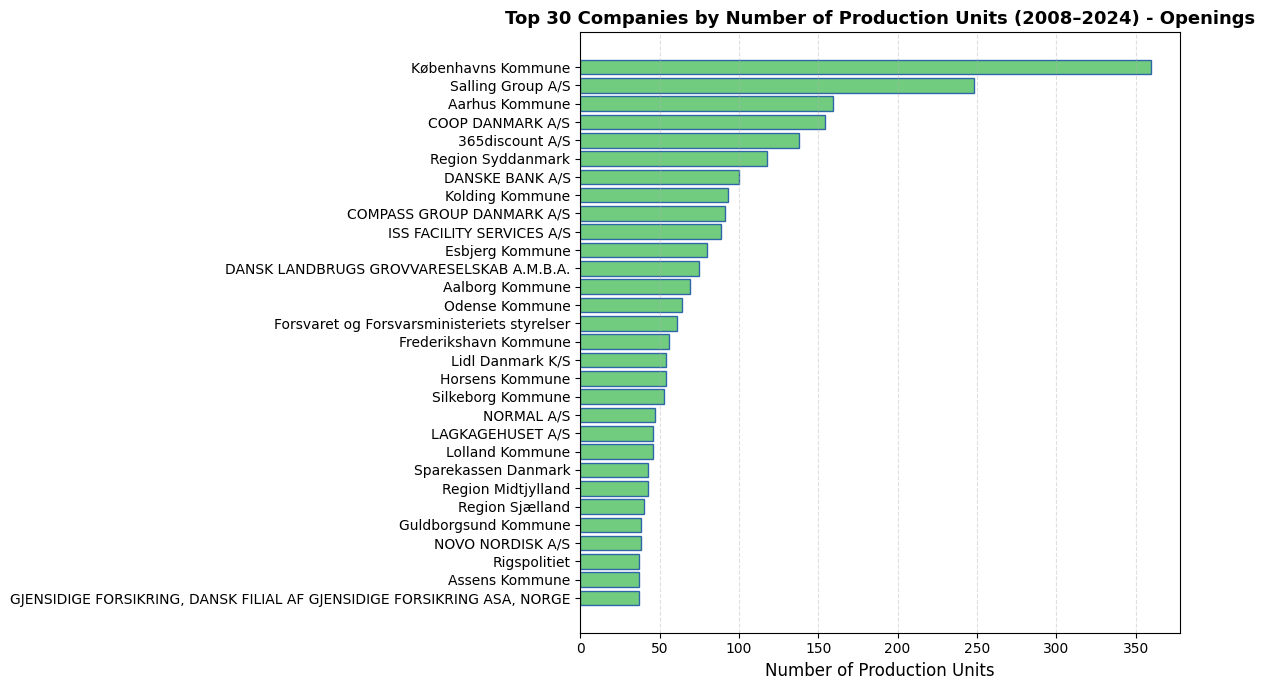

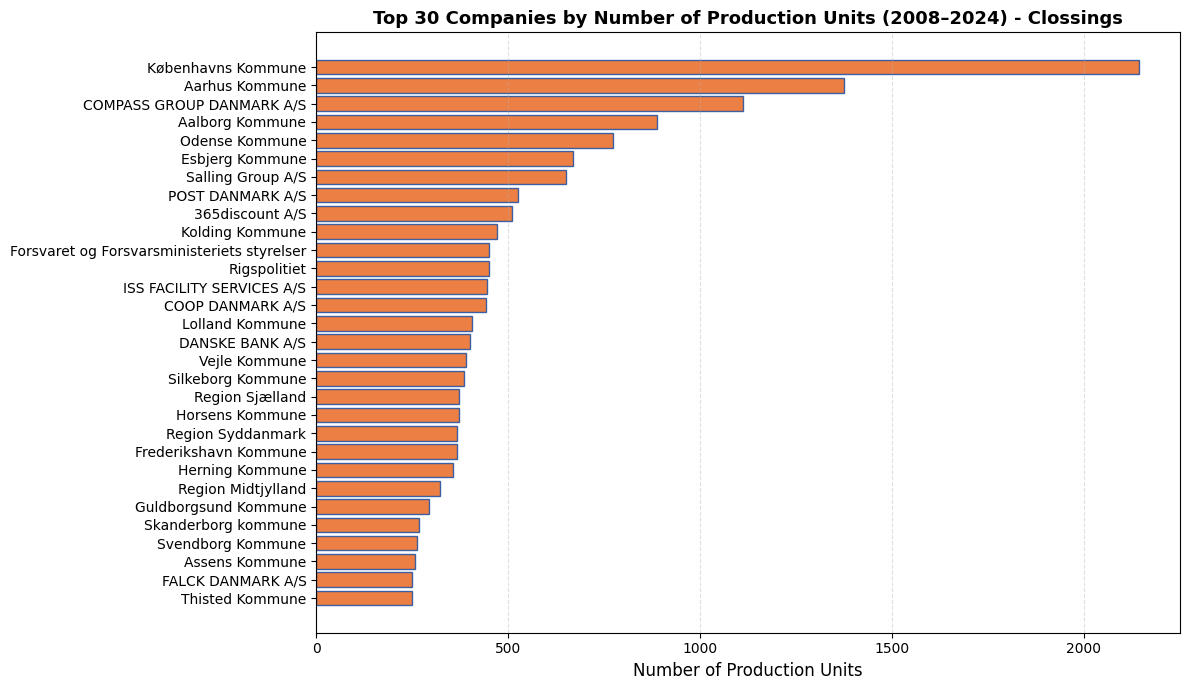

In [ ]:
# Analysis of companies with greatest opened units between 2008 and 2024
df_pUnit = pd.read_csv('src/Part2/data/cvr_production_units_geocoded.csv', encoding='utf-8')
df_plot = df_pUnit.dropna(subset=['Lat', 'Lon']).copy()

# Select only production units that closed after 2008
df_plot_openings = df_plot[
    (df_plot['UnitStartdate'] >= '2008-01-01') | (df_plot['UnitEnddate'] == None)
].copy()

df_plot_closings = df_plot[
   (df_plot['UnitStartdate'] < '2008-01-01') | (df_plot['UnitEnddate'] >= '2008-01-01')
].copy()

def plot_company_units(df, title,color, top_n=30):
    company_counts = (
        df.groupby('CompanyName')
        .size()
        .reset_index(name='UnitCount')
        .sort_values('UnitCount', ascending=False)
    )

    #  # Remove companies with 'Kommune' in their name (municipalities)
    # bf = len(company_counts)
    # company_counts = company_counts[~company_counts['CompanyName'].str.contains('Kommune|Region', case=False, na=False)]
    # # Remove suppermarkets and retail chains
    # company_counts = company_counts[~company_counts['CompanyName'].str.contains('Salling|365discount|COOP|POST|politi|COMPASS', case=False, na=False)]
    # print(f"Removed {bf - len(company_counts)} companies.")
    
    df_top = company_counts.head(top_n)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(df_top['CompanyName'][::-1], df_top['UnitCount'][::-1], color=color, edgecolor='#0d47a1', alpha=0.8)
    ax.set_xlabel('Number of Production Units', fontsize=12)
    ax.set_title(f'Top {top_n} Companies by Number of Production Units (2008–2024) - {title}', fontsize=13, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

for df, title, color, n_comp in [
    (df_plot_openings,"Openings", "#4fc060", 30),
    (df_plot_closings, "Clossings", "#e85f14", 30)
    ]:
    plot_company_units(df, title, color, top_n=n_comp)

To understand how industry and business presence affects municipal wealth and demographics, we first looked at the national macro-trend of enterprise openings and closings. The plot below illustrates the aggregate net change of production units across Denmark from 2008 to 2024. 

We can clearly see the impact of major economic events, such as the sharp drop during the 2008 Financial Crisis and the volatility during the 2020 COVID pandemic. Observing these significant national fluctuations motivated the creation of more localized visualisations, specifically the scatter plot (comparing net unit change to population change , `src/Part2/scatter_visz.py`) and the geographical bubble maps (`src/Part2/map_population_income_plotly_folium.py`). We wanted to answer: *Are these openings and closings evenly distributed, or do specific municipalities absorb the growth while others bear the brunt of the closures?* And more importantly, *does a localized increase in active production units translate to localized population and income growth?*

In [3]:
panel = pd.read_csv('src/Part2/data/kommune_year_panel.csv')

national = panel.groupby("year").agg(
    openings=("openings", "sum"),
    closings=("closings", "sum"),
    net_change=("net_change", "sum"),
).reset_index()

fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=national["year"], y=national["openings"], name="Openings",
                          mode="lines+markers", line=dict(color="#2ca02c", width=3)))
fig1.add_trace(go.Scatter(x=national["year"], y=national["closings"], name="Closings",
                          mode="lines+markers", line=dict(color="#d62728", width=3)))
fig1.add_trace(go.Bar(x=national["year"], y=national["net_change"], name="Net change",
                      marker_color=["#2ca02c" if v >= 0 else "#d62728" for v in national["net_change"]],
                      opacity=0.35, yaxis="y2"))

# Annotate macro events
fig1.add_vrect(x0=2008.5, x1=2009.5, fillcolor="gray", opacity=0.1, line_width=0,
               annotation_text="Financial crisis", annotation_position="top left")
fig1.add_vrect(x0=2019.5, x1=2020.5, fillcolor="gray", opacity=0.1, line_width=0,
               annotation_text="COVID", annotation_position="top left")

fig1.update_layout(
    title="Production unit openings and closings, Denmark 2008–2024",
    xaxis_title="Year",
    yaxis=dict(title="Openings / Closings (units per year)"),
    yaxis2=dict(title="Net change", overlaying="y", side="right", showgrid=False),
    hovermode="x unified",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig1.show()

### Part 3: Socio-economical status to Education to Industry Pipeline (Uliyan Sukach)
*The Sankey comparison suggests that large university cities are more strongly connected to higher education and knowledge-intensive industry sectors, while more outlying or industrial municipalities are more closely linked to bachelor-and-lower education, manufacturing, trade and transportation. Employment is often higher in municipalities with stronger industrial or business activity, while university-oriented municipalities may have a larger share of people enrolled in education, and therfore lower employment share.*

In [5]:
# get data
edu=pd.read_csv("data/HFUDD16_Final_Readable.csv")
inc=pd.read_csv("data/IFOR35_Final_Readable.csv")

Lets see how socio-economic status, and degree types differ across municipalities. 

In [6]:

import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output


edu_dash = edu.copy()

# create proportions by municipality and year

df = edu_dash.copy()

# Remove national / aggregate rows if they exist
df = df[~df["Region_Name"].isin(["All municipalities", "Hele landet", "Denmark"])].copy()

# Standardize text
df["Education_Level"] = df["Education_Level"].astype(str).str.strip()
df["Socioeconomic_Status"] = df["Socioeconomic_Status"].astype(str).str.strip()

# Total population/count by municipality-year
total = (
    df.groupby(["Region_Name", "Year"], as_index=False)["Count"]
    .sum()
    .rename(columns={"Count": "Total_Count"})
)

# Employed count
employed = (
    df[df["Socioeconomic_Status"] == "Employed"]
    .groupby(["Region_Name", "Year"], as_index=False)["Count"]
    .sum()
    .rename(columns={"Count": "Employed_Count"})
)

# Education counts
edu_counts = (
    df.groupby(["Region_Name", "Year", "Education_Level"], as_index=False)["Count"]
    .sum()
)

# Make education table wide
edu_wide = edu_counts.pivot_table(
    index=["Region_Name", "Year"],
    columns="Education_Level",
    values="Count",
    aggfunc="sum",
    fill_value=0
).reset_index()

# Merge everything
prop_df = total.merge(employed, on=["Region_Name", "Year"], how="left")
prop_df = prop_df.merge(edu_wide, on=["Region_Name", "Year"], how="left")

prop_df["Employed_Count"] = prop_df["Employed_Count"].fillna(0)

# Helper function in case some education columns are missing
def safe_col(data, col):
    if col in data.columns:
        return data[col]
    return 0

# Adjust these names if your categories are named differently
prop_df["Prop_Employed"] = prop_df["Employed_Count"] / prop_df["Total_Count"]
prop_df["Prop_Bachelor_Lower"] = safe_col(prop_df, "Bachelor and lower") / prop_df["Total_Count"]
prop_df["Prop_Master"] = safe_col(prop_df, "Master") / prop_df["Total_Count"]
prop_df["Prop_PhD"] = safe_col(prop_df, "PhD") / prop_df["Total_Count"]

# Long format for plotting
prop_long = prop_df.melt(
    id_vars=["Region_Name", "Year", "Total_Count"],
    value_vars=[
        "Prop_Employed",
        "Prop_Bachelor_Lower",
        "Prop_Master",
        "Prop_PhD"
    ],
    var_name="Metric",
    value_name="Proportion"
)

metric_labels = {
    "Prop_Employed": "Employed",
    "Prop_Bachelor_Lower": "Bachelor and lower",
    "Prop_Master": "Master",
    "Prop_PhD": "PhD"
}

prop_long["Metric"] = prop_long["Metric"].map(metric_labels)

prop_df.head()

,Region_Name,Year,Total_Count,Employed_Count,Bachelor and lower,Master,Not stated,PhD,Prop_Employed,Prop_Bachelor_Lower,Prop_Master,Prop_PhD
0,Aabenraa,2008,23731,21601,22430,902,380,19,0.910244,0.945177,0.038009,0.000801
1,Aabenraa,2009,22478,20505,21245,884,327,22,0.912225,0.945146,0.039327,0.000979
2,Aabenraa,2010,22096,20103,20863,903,309,21,0.909803,0.944198,0.040867,0.000950
3,Aabenraa,2011,21804,19722,20574,923,283,24,0.904513,0.943588,0.042332,0.001101
4,Aabenraa,2012,21306,19293,20065,947,267,27,0.905520,0.941753,0.044448,0.001267


#### Plot histograms

In [7]:
import plotly.express as px

# Choose year
selected_year = prop_df["Year"].max()

plot_df = prop_df[prop_df["Year"] == selected_year].copy()

# =========================================================
# 1. Master proportion across municipalities
# =========================================================

fig_master = px.histogram(
    plot_df,
    x="Prop_Master",
    nbins=30,
    title=f"Distribution of Master share across municipalities, {selected_year}",
    labels={"Prop_Master": "Share with Master"}
)

fig_master.update_layout(
    xaxis_tickformat=".0%",
    width=750,
    height=420
)

fig_master.show()


# =========================================================
# 2. PhD proportion across municipalities
# =========================================================

fig_phd = px.histogram(
    plot_df,
    x="Prop_PhD",
    nbins=30,
    title=f"Distribution of PhD share across municipalities, {selected_year}",
    labels={"Prop_PhD": "Share with PhD"}
)

fig_phd.update_layout(
    xaxis_tickformat=".1%",
    width=750,
    height=420
)

fig_phd.show()


# =========================================================
# 3. Bachelor and lower proportion across municipalities
# =========================================================

fig_bachelor = px.histogram(
    plot_df,
    x="Prop_Bachelor_Lower",
    nbins=30,
    title=f"Distribution of Bachelor and lower share across municipalities, {selected_year}",
    labels={"Prop_Bachelor_Lower": "Share with Bachelor and lower"}
)

fig_bachelor.update_layout(
    xaxis_tickformat=".0%",
    width=750,
    height=420
)

fig_bachelor.show()


# =========================================================
# 4. Employed proportion across municipalities
# =========================================================

fig_employed = px.histogram(
    plot_df,
    x="Prop_Employed",
    nbins=30,
    title=f"Distribution of employed share across municipalities, {selected_year}",
    labels={"Prop_Employed": "Share employed"}
)

fig_employed.update_layout(
    xaxis_tickformat=".0%",
    width=750,
    height=420
)

fig_employed.show()

The distributions show that municipalities differ clearly in both education level and employment structure. Master’s and PhD shares are concentrated in a smaller number of municipalities, while bachelor-and-lower education is high in most municipalities. Employment shares are more similar across municipalities, but still show some variation.

This motivates the analysis: to explore how education and socioeconomic status differ between municipalities, how they change over time, and how they relate to the industries present in each municipality 



#### Sankey plot

We create a Sankey plot that links education level, socioeconomic status, and industry for each municipality and year. This makes it possible to see how different education groups are connected to employment status and industry structure.
The dashboard also allows us to compare two municipalities side by side. This helps reveal differences in educational composition, labour-market status, and the industries that dominate in each municipality over time.

In [8]:
import pandas as pd
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output


# =========================================================
# 1. CLEAN DATA
# =========================================================

edu_dash = edu.copy()

text_cols = [
    "Region_Name",
    "Education_Level",
    "Socioeconomic_Status",
    "Industry_Group",
    "Age_Group"
]

for col in text_cols:
    edu_dash[col] = edu_dash[col].astype(str).str.strip()

edu_dash["Year"] = pd.to_numeric(edu_dash["Year"], errors="coerce")
edu_dash["Count"] = pd.to_numeric(edu_dash["Count"], errors="coerce")

edu_dash = edu_dash.dropna(subset=[
    "Region_Name",
    "Education_Level",
    "Socioeconomic_Status",
    "Industry_Group",
    "Age_Group",
    "Year",
    "Count"
])

edu_dash["Year"] = edu_dash["Year"].astype(int)
edu_dash = edu_dash[edu_dash["Count"] > 0].copy()


# =========================================================
# 2. SANKEY FUNCTION
# Education -> Status -> Industry -> Education
# =========================================================

def make_education_status_industry_education_sankey(
    edu,
    municipality="All municipalities",
    year=None,
    age_group="All",
    value_mode="proportion",   # "count" or "proportion"
    min_value=0,
    title_suffix=""
):
    d = edu.copy()

    if municipality != "All municipalities":
        d = d[d["Region_Name"] == municipality]

    if year is not None:
        d = d[d["Year"] == year]

    if age_group != "All":
        d = d[d["Age_Group"] == age_group]

    if d.empty:
        fig = go.Figure()
        fig.update_layout(
            title=f"No data for {municipality}",
            width=650,
            height=430
        )
        return fig

    d["Education_Level"] = d["Education_Level"].astype(str).str.strip()
    d["Socioeconomic_Status"] = d["Socioeconomic_Status"].astype(str).str.strip()
    d["Industry_Group_Clean"] = d["Industry_Group"].astype(str).str.strip()

    missing_industry = (
        d["Industry_Group_Clean"].isna()
        | (d["Industry_Group_Clean"] == "")
        | d["Industry_Group_Clean"].str.lower().isin([
            "nan",
            "none",
            "not stated",
            "not applicable"
        ])
    )

    d.loc[missing_industry, "Industry_Group_Clean"] = "No industry / not employed"

    non_employed_statuses = [
        "Unemployed",
        "Outside the labour force",
        "Enrolled in education"
    ]

    d.loc[
        d["Socioeconomic_Status"].isin(non_employed_statuses),
        "Industry_Group_Clean"
    ] = "No industry / not employed"

    # =====================================================
    # Counts vs proportions
    # =====================================================

    total_count = d["Count"].sum()

    if value_mode == "proportion":
        d["Sankey_Value"] = d["Count"] / total_count
        title_value_note = "Proportions"
        node_hovertemplate = "%{label}<br>Total share: %{value:.1%}<extra></extra>"
        link_hovertemplate = (
            "%{source.label} → %{target.label}<br>"
            "Share of total: %{value:.1%}<extra></extra>"
        )
    else:
        d["Sankey_Value"] = d["Count"]
        title_value_note = "Counts"
        node_hovertemplate = "%{label}<br>Total count: %{value:,.0f}<extra></extra>"
        link_hovertemplate = (
            "%{source.label} → %{target.label}<br>"
            "Count: %{value:,.0f}<extra></extra>"
        )

    # Duplicate education layer so Plotly does not merge start and end education nodes
    d["Education_Start"] = d["Education_Level"] + " [education start]"
    d["Education_End"] = d["Education_Level"] + " [education end]"

    # Flow 1: Education -> Status
    flow1 = (
        d.groupby(["Education_Start", "Socioeconomic_Status"], as_index=False)["Sankey_Value"]
        .sum()
        .rename(columns={
            "Education_Start": "source",
            "Socioeconomic_Status": "target",
            "Sankey_Value": "value"
        })
    )

    # Flow 2: Status -> Industry
    flow2 = (
        d.groupby(["Socioeconomic_Status", "Industry_Group_Clean"], as_index=False)["Sankey_Value"]
        .sum()
        .rename(columns={
            "Socioeconomic_Status": "source",
            "Industry_Group_Clean": "target",
            "Sankey_Value": "value"
        })
    )

    # Flow 3: Industry -> Education copy
    flow3 = (
        d.groupby(["Industry_Group_Clean", "Education_End"], as_index=False)["Sankey_Value"]
        .sum()
        .rename(columns={
            "Industry_Group_Clean": "source",
            "Education_End": "target",
            "Sankey_Value": "value"
        })
    )

    links = pd.concat([flow1, flow2, flow3], ignore_index=True)
    links = links[links["value"] > min_value].copy()

    if links.empty:
        fig = go.Figure()
        fig.update_layout(
            title=f"No links for {municipality}",
            width=650,
            height=430
        )
        return fig

    labels_raw = pd.Index(pd.concat([links["source"], links["target"]]).unique())
    label_to_id = {label: i for i, label in enumerate(labels_raw)}

    labels_display = [
        label
        .replace(" [education start]", "")
        .replace(" [education end]", "")
        for label in labels_raw
    ]

    title = f"{municipality}<br>{year} — {title_value_note}"

    if age_group != "All":
        title += f", {age_group}"

    if title_suffix:
        title += f"<br>{title_suffix}"

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=4,
            thickness=6,
            line=dict(width=0.2),
            label=labels_display,
            hovertemplate=node_hovertemplate
        ),
        link=dict(
            source=links["source"].map(label_to_id),
            target=links["target"].map(label_to_id),
            value=links["value"],
            hovertemplate=link_hovertemplate
        )
    )])

    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            xanchor="center",
            font=dict(size=12)
        ),
        font_size=7,
        width=650,
        height=430,
        margin=dict(l=2, r=2, t=55, b=5)
    )

    return fig


# =========================================================
# 3. DASH OPTIONS
# =========================================================

municipalities = ["All municipalities"] + sorted(edu_dash["Region_Name"].dropna().unique())
age_groups = ["All"] + sorted(edu_dash["Age_Group"].dropna().unique())

years = sorted(edu_dash["Year"].dropna().astype(int).unique())
initial_year = years[0]


# =========================================================
# 4. DASH APP
# =========================================================

app = Dash(__name__)

app.layout = html.Div(
    style={
        "fontFamily": "Arial, sans-serif",
        "maxWidth": "1350px",
        "margin": "0 auto",
        "padding": "6px"
    },
    children=[
        html.H2(
            "Municipality comparison: Education → Status → Industry → Education",
            style={
                "textAlign": "center",
                "fontSize": "18px",
                "marginBottom": "6px"
            }
        ),

        html.Div(
            style={
                "display": "grid",
                "gridTemplateColumns": "1fr 1fr 0.8fr 0.8fr",
                "gap": "10px",
                "fontSize": "12px",
                "marginBottom": "8px"
            },
            children=[
                html.Div([
                    html.Label("Municipality A"),
                    dcc.Dropdown(
                        id="municipality-a",
                        options=[{"label": m, "value": m} for m in municipalities],
                        value=municipalities[0],
                        clearable=False,
                        style={"fontSize": "12px"}
                    )
                ]),

                html.Div([
                    html.Label("Municipality B"),
                    dcc.Dropdown(
                        id="municipality-b",
                        options=[{"label": m, "value": m} for m in municipalities],
                        value=municipalities[1] if len(municipalities) > 1 else municipalities[0],
                        clearable=False,
                        style={"fontSize": "12px"}
                    )
                ]),

                html.Div([
                    html.Label("Age group"),
                    dcc.Dropdown(
                        id="age-group-dropdown",
                        options=[{"label": a, "value": a} for a in age_groups],
                        value="All",
                        clearable=False,
                        style={"fontSize": "12px"}
                    )
                ]),

                html.Div([
                    html.Label("Value mode"),
                    dcc.RadioItems(
                        id="value-mode",
                        options=[
                            {"label": "Counts", "value": "count"},
                            {"label": "Proportions", "value": "proportion"}
                        ],
                        value="proportion",
                        inline=False,
                        style={"fontSize": "12px"}
                    )
                ])
            ]
        ),

        html.Div(
            style={
                "fontSize": "12px",
                "marginBottom": "4px"
            },
            children=[
                html.Label("Year"),
                dcc.Slider(
                    id="year-slider",
                    min=years[0],
                    max=years[-1],
                    step=None,
                    value=initial_year,
                    marks={
                        int(y): {
                            "label": str(y),
                            "style": {"fontSize": "10px"}
                        }
                        for y in years
                    },
                    tooltip={
                        "placement": "bottom",
                        "always_visible": False
                    }
                )
            ]
        ),

        html.Div(
            style={
                "display": "grid",
                "gridTemplateColumns": "1fr 1fr",
                "gap": "4px"
            },
            children=[
                dcc.Graph(
                    id="sankey-a",
                    config={"displayModeBar": False, "responsive": True},
                    style={"height": "450px"}
                ),
                dcc.Graph(
                    id="sankey-b",
                    config={"displayModeBar": False, "responsive": True},
                    style={"height": "450px"}
                )
            ]
        )
    ]
)


# =========================================================
# 5. UPDATE BOTH SANKEYS
# =========================================================

@app.callback(
    Output("sankey-a", "figure"),
    Output("sankey-b", "figure"),
    Input("municipality-a", "value"),
    Input("municipality-b", "value"),
    Input("year-slider", "value"),
    Input("age-group-dropdown", "value"),
    Input("value-mode", "value")
)
def update_comparison(muni_a, muni_b, year, age_group, value_mode):
    fig_a = make_education_status_industry_education_sankey(
        edu=edu_dash,
        municipality=muni_a,
        year=int(year),
        age_group=age_group,
        value_mode=value_mode,
        min_value=0
    )

    fig_b = make_education_status_industry_education_sankey(
        edu=edu_dash,
        municipality=muni_b,
        year=int(year),
        age_group=age_group,
        value_mode=value_mode,
        min_value=0
    )

    return fig_a, fig_b


# =========================================================
# 6. RUN APP
# =========================================================

app.run(debug=True, port=8051)

**Development of ALL - municipalities**

When interpreting the plot for all of Denmark across the available years, we see a clear development toward higher educational attainment. Over time, a larger share of the population holds a master’s degree, and more people are enrolled in education.

At the same time, we also see more people with master’s degrees represented in the labour market. Industries such as Consultancy, R&D and Business Services grow over time, while Education, Health, Arts and Recreation remains one of the largest industry groups. This pattern makes sense, as a more highly educated population is often more represented in knowledge-intensive and public-service sectors. 

**Municipality comparison**
When comparing municipalities, we choose places with different profiles. For example, Lyngby-Taarbæk is a municipality with a strong educational and research environment, while Kolding have a different industrial and business structure.

In **Lyngby-Taarbæk**, a larger share of the population has a master’s degree, and there are also more PhD graduates compared with Kolding. However, the share of people with master’s degrees increases in both municipalities over time. In **Kolding**, the share of people with “Bachelor and lower” education is higher across most industries.


**Kolding** has a higher number of employed people across the period, but employment decreases during parts of 2009–2016 before increasing again later. This may partly be explained by the situation after the financial crisis in 2008, since Kolding has a stronger connection to business-oriented and production-related sectors, which may be more sensitive to economic downturns. In contrast, **Lyngby-Taarbæk** has a more stable employment pattern, possibly because a larger share of its population is connected to education, research and knowledge-intensive sectors.

Manufacturing is more prominent in Kolding than in Lyngby-Taarbæk, although it declines over time. In Lyngby-Taarbæk, manufacturing plays a smaller role, while Consultancy, R&D and Business Services has a larger role and grows over time. This difference may be related to the higher concentration of master’s and PhD graduates in Lyngby-Taarbæk, which fits well with the municipality’s stronger connection to education, research and knowledge-intensive industries.

By comparing municipalities, we can see how education levels, socioeconomic status and industry structure differ across Denmark. When comparing large urban municipalities with more outlying or industrial areas.

**Large university cities may have**

- higher shares of master’s and PhD graduates
- more people enrolled in education
- stronger links to consultancy, R&D and business services
- lower employed share because more people are enrolled in education, even though they often have many highly educated people

**More outlying or industrial municipalities may have**

- higher shares of “Bachelor and lower” education
- stronger links to manufacturing, trade and transportation
- different employment patterns over time
- higher employed share because a larger part of the population is directly connected to the labour market


## 4. Genre

We used the **Partitioned Poster** genre combined with a **Martini Glass** narrative structure.

### Visual Narrative
* **Consistent Visual Platform:** We built all visualizations using Plotly so the design and interaction logic remain standardized across the page.
* **Feature Distinction & Close-ups:** In the dashboard, clicking a municipality highlights it on the map and isolates its specific data point on the ternary plot, acting as a close-up.
* **Familiar Objects:** We use a map of Denmark as the primary navigation tool, giving users an intuitive way to filter complex demographic data.

### Narrative Structure
* **Linear Ordering:** The top sections of the webpage dictate the reading order. We guide the user through national trends, industry impact, and education flows.
* **Filtering / Selection:** At the bottom of each section, we provide interactive tools (Dash and Plotly elements) so the user can filter the data themselves.
* **Multi-messaging:** Each chart is paired with dedicated text blocks that explicitly state the main takeaway before the user interacts with the visualization.

## 5. Visualizations

### The Interactive Map & Ternary Plot (Andrea De Pascale)
* **Choropleth Map:** This shows the spatial distribution of wealth, making it easy to identify high-income and low-income regions.
* **Ternary Plot:** Socioeconomic status (Employed, Unemployed, Enrolled) is compositional data. A ternary plot is the standard method for visualizing three variables that represent parts of a whole.
* **Why they fit the story:** Cross-filtering these plots proves the concept of demographic uniformity. When users click on municipalities with drastically different income levels on the map, the highlighted point on the ternary plot barely moves.

### Industry Distribution Plots & Maps (Edgar Fabregat)
* **Horizontal Bar Charts (Openings/Closings):** Displays the top 30 companies responsible for the most production unit openings and closings between 2008 and 2024.
* **Net Unit Change vs Population Scatter Plot:** Visualizes the relationship between the percentage change in active production units and the percentage change in population from 2008 to 2024.
* **Bubble Overlay Maps:** Choropleth maps of population and income changes, overlaid with bubbles sized and colored by the net change of production units in each municipality.
* **Why they fit the story:** The bar charts identify exactly *who* (which corporations) is driving the macroeconomic shifts in the industrial landscape. The scatter plot mathematically explores the correlation between business growth and population attraction. Finally, the bubble maps place this geographic context, allowing users to visually cross-reference these localized "business hotspots" (the *where*) with regional wealth and demographic changes, effectively showing *where* industry drives municipal prosperity.

### Socio-economic status, Industry, Education Flow Sankey Diagram (Uliyan Sukach)
* **The Sankey flow:** Shows how education levels are connected to socioeconomic status and industries within a selected municipality and year. Ideal for visualizing interconnections showing both the size and structure of the links.

* **Why they are right for the story:** It fits the story because it makes the connections between education level, socioeconomic status and industry easy to understand in one visual. It also allows us to compare how these patterns differ between municipalities and how they change over time.

## 6. Contributions

While all group members participated in conceptualizing the data story and formatting the final GitHub webpage, the primary technical responsibilities were divided as follows:

* **Andrea De Pascale (s243094):** Led Part 1. Responsible for the loading via API calls and merging of the HFUDD16 and IFOR35 datasets, normalizing municipality GeoJSON data, and building the interactive Dash application. Managed the cloud deployment on Render to enable two-way cross-filtering between the Choropleth map and Ternary plot.
* **Edgar Fabregat:** Led Part 2. Responsible for cleaning and integrating the CVR company location dataset, conducting the exploratory data analysis on national macro-trends vs municipal enterprise performance, and generating the interactive static visualizations (scatter plots and folium/plotly maps) linking industry growth with population and wealth dynamics.
* **Uliyan Sukach (s246457):** Led Part 3. Responsible for mapping the pathways from education levels to industry sectors. Designed and coded the Sankey diagrams to visualize the flow of the workforce.

## 7. References

1. **Statistics Denmark (Danmarks Statistik):**
   * *HFUDD16 Dataset*: Population by education, socioeconomic status, and municipality.
   * *IFOR35 Dataset*: Average income by municipality and deciles.
2. **Segel, E., & Heer, J. (2010):**
   * *Narrative Visualization: Telling Stories with Data*. IEEE Transactions on Visualization and Computer Graphics. (Used for genre and structural framework).
3. **Click That Hood (GitHub):** Open-source repository used for the GeoJSON borders of Danish municipalities.